=== Diagnóstico de Carga ===
   Age Attrition     BusinessTravel              Department  DistanceFromHome  \
0   51        No      Travel_Rarely                   Sales                 6   
1   31       Yes  Travel_Frequently  Research & Development                10   
2   32        No  Travel_Frequently  Research & Development                17   
3   38        No         Non-Travel  Research & Development                 2   
4   32        No      Travel_Rarely  Research & Development                10   

   Education EducationField  EmployeeCount  EmployeeID  Gender  ...  \
0          2  Life Sciences              1           1  Female  ...   
1          1  Life Sciences              1           2  Female  ...   
2          4          Other              1           3    Male  ...   
3          5  Life Sciences              1           4    Male  ...   
4          1        Medical              1           5    Male  ...   

   NumCompaniesWorked Over18 PercentSalaryHike  StandardH

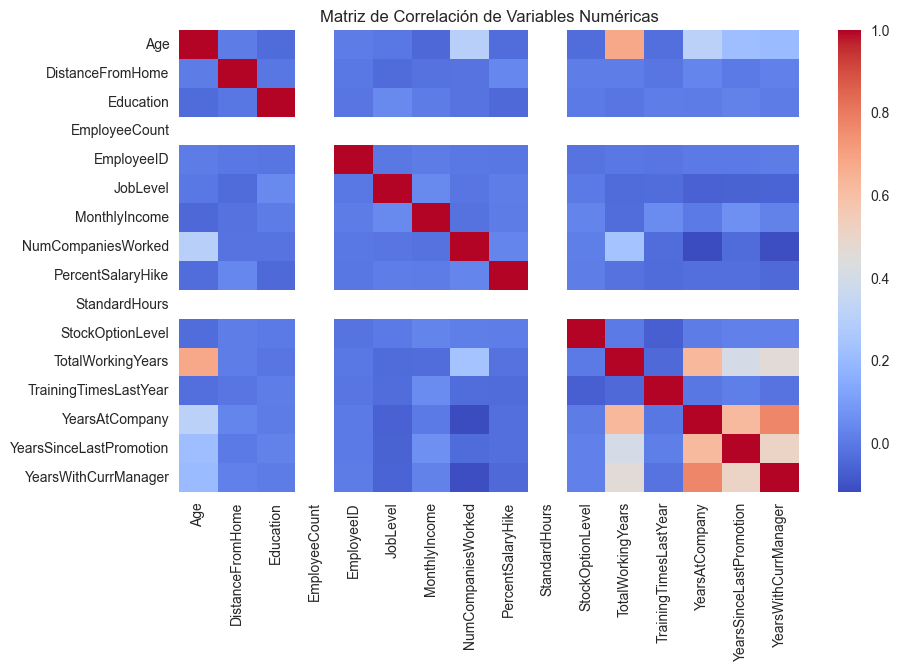


Total de valores nulos post-imputación: 0

=== Métricas del Modelo ===
Accuracy:  0.77
Precisión: 0.80
Recall:    0.71
F1 Score:  0.76


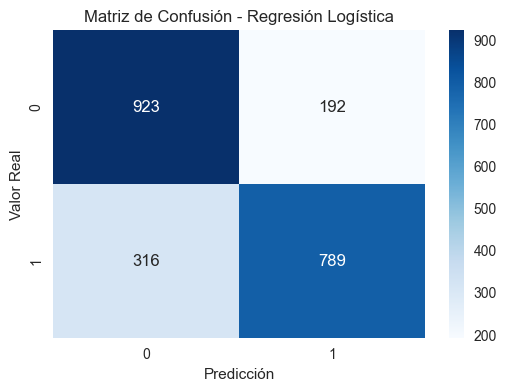

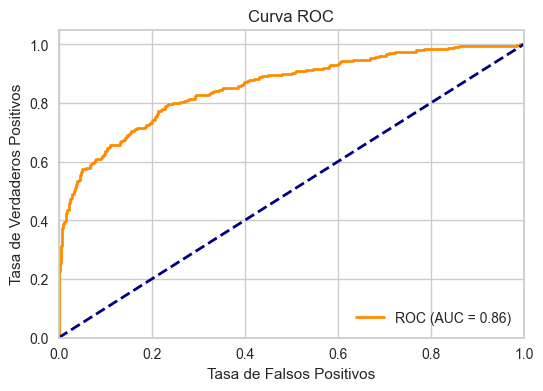


Top 5 variables que INCREMENTAN la probabilidad de salida:
                             Feature  Coeficiente
11           yearssincelastpromotion         0.41
5                 numcompaniesworked         0.32
32              maritalstatus_Single         0.26
13  businesstravel_Travel_Frequently         0.13
10                    yearsatcompany         0.13

Top 5 variables que REDUCEN la probabilidad de salida:
                            Feature  Coeficiente
20             educationfield_Other        -0.61
21  educationfield_Technical Degree        -0.75
18         educationfield_Marketing        -0.75
19           educationfield_Medical        -1.15
17     educationfield_Life Sciences        -1.21


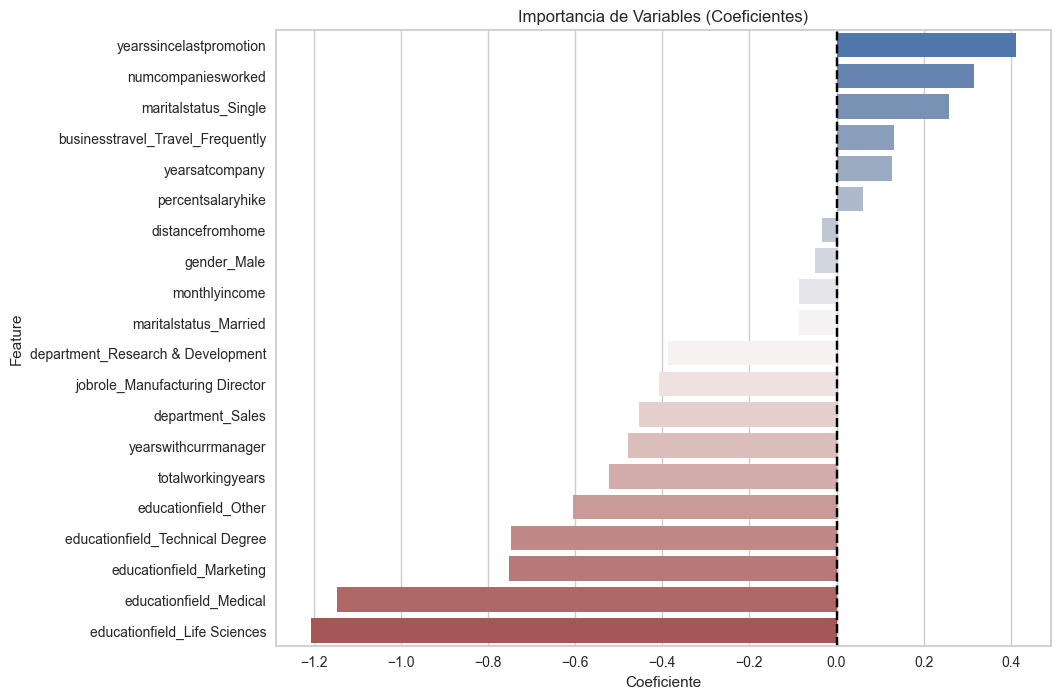

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from imblearn.over_sampling import SMOTE

# Configura la visualización de decimales
pd.options.display.float_format = '{:,.2f}'.format

# ==========================================
# 1. Importación y Diagnóstico Inicial
# ==========================================

# Carga el archivo
ruta_archivo = os.path.join(r'C:\Users\patri\Downloads', 'general_data_.csv')
df = pd.read_csv(ruta_archivo, encoding='latin1')

# Diagnostica la carga de datos
print("=== Diagnóstico de Carga ===")
print(df.head())
print("\nColumnas:")
print(df.columns.tolist())

# ==========================================
# 2. Análisis Exploratorio (EDA Básico)
# ==========================================
# Realiza el análisis antes de modificar las variables para evitar errores

print("\n=== Estructura del DataFrame ===")
print(df.info())

print("\n=== Estadísticas Descriptivas (Numéricas) ===")
print(df.describe())

# Grafica la matriz de correlación para buscar multicolinealidad
plt.figure(figsize=(10, 6))
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# ==========================================
# 3. Preparación y Limpieza de Datos
# ==========================================

# Sanitiza caracteres en los nombres de las columnas
df.columns = df.columns.str.replace('ñ', 'n').str.replace(' ', '_').str.lower()

# Imputa valores nulos (media para numéricos, moda para categóricos)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].mean())

# Valida la limpieza
print(f"\nTotal de valores nulos post-imputación: {df.isnull().sum().sum()}")

# ==========================================
# 4. Feature Engineering
# ==========================================

# Elimina columnas irrelevantes o constantes
columnas_irrelevantes = ['employeecount', 'standardhours', 'over18', 'employeeid']
df = df.drop(columns=[col for col in columnas_irrelevantes if col in df.columns], errors='ignore')

# Convierte la variable objetivo a numérica
if 'attrition' in df.columns:
    df['attrition'] = df['attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Convierte variables categóricas a numéricas usando variables "dummy"
categ_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categ_cols, drop_first=True)

# Separa las características independientes y dependientes
X = df.drop('attrition', axis=1)
y = df['attrition']

# Ajusta proporciones para evitar sesgos con SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42)

# Ajusta variables numéricas a media 0 y desviación 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. Entrenamiento y Predicción
# ==========================================

# Ajusta Regresión Logística con el conjunto de entrenamiento
modelo_rl = LogisticRegression(max_iter=1000, random_state=42)
modelo_rl.fit(X_train_scaled, y_train)

# Genera las predicciones
y_pred = modelo_rl.predict(X_test_scaled)
y_prob = modelo_rl.predict_proba(X_test_scaled)[:, 1]

# ==========================================
# 6. Evaluación del Modelo
# ==========================================

# Calcula Accuracy, Precisión, Recall y F1 Score
print("\n=== Métricas del Modelo ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Precisión: {precision_score(y_test, y_pred):.2f}")
print(f"Recall:    {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.2f}")

# Revisa predicciones correctas e incorrectas
matriz_conf = confusion_matrix(y_test, y_pred)

# Grafica la Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Grafica el rendimiento del modelo binario (Curva ROC)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# ==========================================
# 7. Análisis de Sensibilidad
# ==========================================

# Extrae e identifica patrones significativos en los coeficientes
importancia_features = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo_rl.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("\nTop 5 variables que INCREMENTAN la probabilidad de salida:")
print(importancia_features.head(5))

print("\nTop 5 variables que REDUCEN la probabilidad de salida:")
print(importancia_features.tail(5))

# Grafica el análisis de sensibilidad
top_features = pd.concat([importancia_features.head(10), importancia_features.tail(10)])

plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Feature', data=top_features, hue='Feature', palette='vlag', legend=False)
plt.title('Importancia de Variables (Coeficientes)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

Versión de Matplotlib cargada: 3.5.3
Preparando el entorno mágico de PyCaret...

=== Iniciando Batalla de Modelos ===


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9731,0.9918,0.9731,0.9731,0.9724,0.8956,0.8982,0.1600
rf,Random Forest Classifier,0.9718,0.9866,0.9718,0.9718,0.9710,0.8901,0.8931,0.2250
dt,Decision Tree Classifier,0.9573,0.9186,0.9573,0.9572,0.9571,0.8412,0.8416,0.0680
gbc,Gradient Boosting Classifier,0.8653,0.8418,0.8653,0.8564,0.8592,0.4602,0.4649,0.3750
dummy,Dummy Classifier,0.8387,0.5000,0.8387,0.7034,0.7651,0.0000,0.0000,0.0550
knn,K Neighbors Classifier,0.8108,0.9181,0.8108,0.8886,0.8316,0.4924,0.5382,0.4700
ada,Ada Boost Classifier,0.7924,0.7398,0.7924,0.8050,0.7979,0.2760,0.2777,0.1460
lr,Logistic Regression,0.6923,0.7512,0.6923,0.8208,0.7306,0.2518,0.2914,0.8080
ridge,Ridge Classifier,0.6910,0.0000,0.6910,0.8213,0.7296,0.2517,0.2923,0.0710
lda,Linear Discriminant Analysis,0.6910,0.7498,0.6910,0.8213,0.7296,0.2517,0.2923,0.0660



¡Batalla terminada! El mejor algoritmo para predecir la rotación es:
ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=42, verbose=0, warm_start=False)


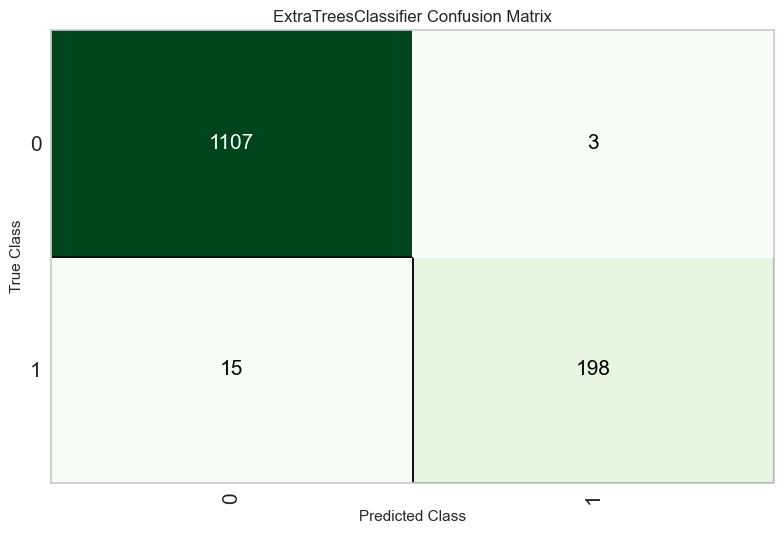

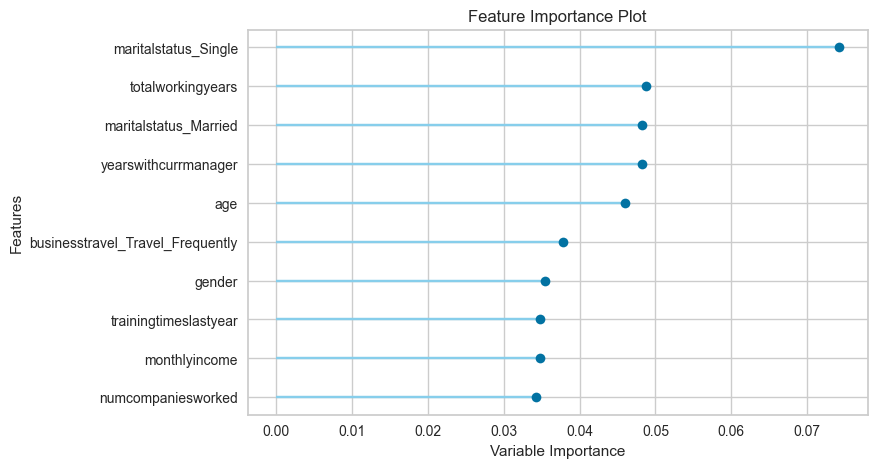

In [5]:
import matplotlib
print(f"Versión de Matplotlib cargada: {matplotlib.__version__}")
# ==========================================
# 8. BONUS: PyCaret (AutoML)
# ==========================================
import pandas as pd
import os
from pycaret.classification import *

print("Preparando el entorno mágico de PyCaret...")

# 1. Cargar los datos crudos
ruta_archivo = os.path.join(r'C:\Users\patri\Downloads', 'general_data_.csv')
df_pycaret = pd.read_csv(ruta_archivo, encoding='latin1')

# Sanitizar columnas y eliminar la "basura" constante que descubrimos en el EDA
df_pycaret.columns = df_pycaret.columns.str.replace('ñ', 'n').str.replace(' ', '_').str.lower()
columnas_basura = ['employeecount', 'standardhours', 'over18', 'employeeid']
df_pycaret = df_pycaret.drop(columns=[col for col in columnas_basura if col in df_pycaret.columns], errors='ignore')

# 2. Inicializar el entorno (Aquí ocurre todo el Feature Engineering automáticamente)
# Para solucionar la multicolinealidad, le decimos que ignore una de las variables correlacionadas
experimento = setup(
    data = df_pycaret,
    target = 'attrition',
    session_id = 42,
    fix_imbalance = True,              # Aplica SMOTE automáticamente
    normalize = True,                  # Ajusta media a 0 y desviación a 1
    ignore_features = ['yearsatcompany'], # Reducimos la multicolinealidad
    verbose = False                    # Oculta logs innecesarios
)

# 3. Entrenar y comparar TODOS los modelos
print("\n=== Iniciando Batalla de Modelos ===")
mejor_modelo = compare_models()

# 4. Mostrar el ganador
print("\n¡Batalla terminada! El mejor algoritmo para predecir la rotación es:")
print(mejor_modelo)

# 5. Generar gráficas automáticas del modelo ganador
plot_model(mejor_modelo, plot='confusion_matrix')
plot_model(mejor_modelo, plot='feature')